# UAS Pengolahan Citra Digital
## Deteksi Buah dan Daun (Studi Kasus: Nanas)

## 1. Import Library

In [13]:
# Muhammad Khasyi Athallah
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## 2. Membaca Citra Asli

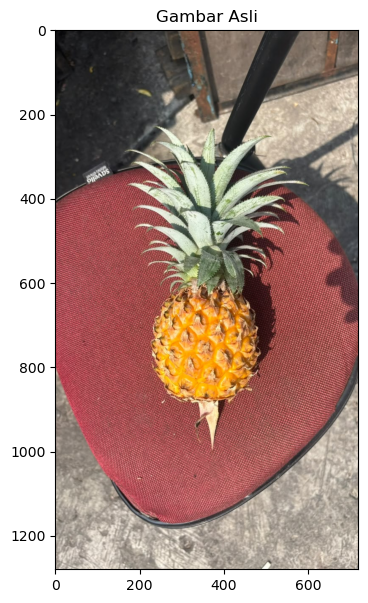

Ukuran citra (tinggi, lebar, channel): (1280, 720, 3)


In [36]:
# Muhammad Khasyi Athallah
image_path = 'nanas.jpeg'  

img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5,7))
plt.imshow(img_rgb)
plt.title('Gambar Asli')
plt.show()

print('Ukuran citra (tinggi, lebar, channel):', img_rgb.shape)

## 3. Konversi ke Ruang Warna HSV

In [37]:
# Muhammad Khasyi Athallah
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

## 4. Membuat Mask Buah Nanas

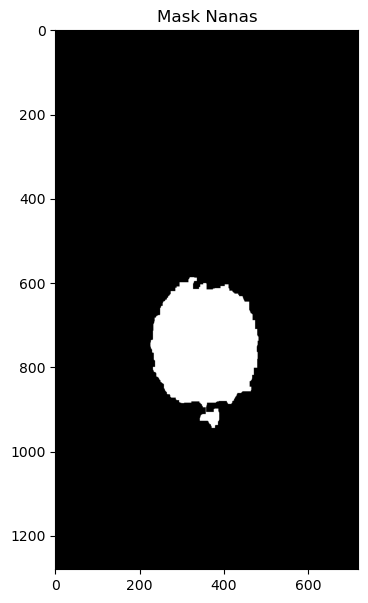

In [38]:
# Muhammad Khasyi Athallah
lower_fruit = np.array([5, 70, 60])
upper_fruit = np.array([30, 255, 255])

mask_fruit = cv2.inRange(img_hsv, lower_fruit, upper_fruit)

kernel = np.ones((7, 7), np.uint8)
mask_fruit = cv2.morphologyEx(mask_fruit, cv2.MORPH_OPEN, kernel)
mask_fruit = cv2.morphologyEx(mask_fruit, cv2.MORPH_CLOSE, kernel, iterations=2)


n_label, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_fruit, connectivity=8)
if n_label > 1:
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    mask_fruit = np.uint8(labels == largest_label) * 255

plt.figure(figsize=(5,7))
plt.imshow(mask_fruit, cmap='gray')
plt.title('Mask Nanas')
plt.show()

## 5. Segmentasi Buah Nanas

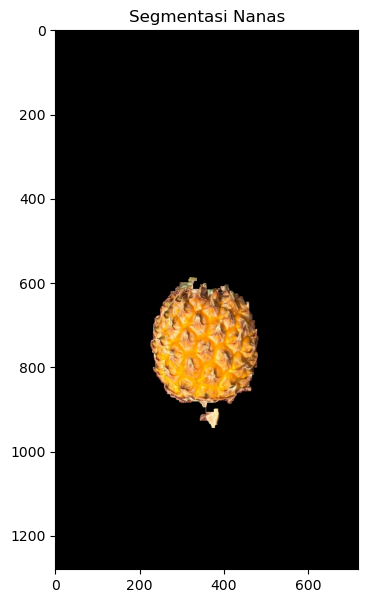

In [32]:
# Muhammad Khasyi Athallah
segmentasi_nanas = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_fruit)

plt.figure(figsize=(5,7))
plt.imshow(segmentasi_nanas)
plt.title('Segmentasi Nanas')
plt.show()

## 6. Membuat Mask Daun (Mahkota Nanas)

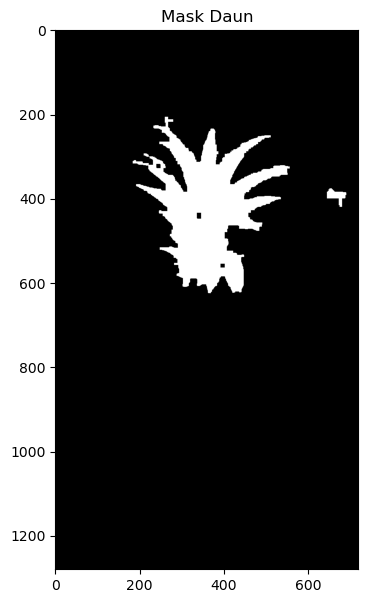

In [33]:
# Muhammad Khasyi Athallah
lower_leaf = np.array([25, 15, 60])
upper_leaf = np.array([95, 255, 255])

mask_leaf = cv2.inRange(img_hsv, lower_leaf, upper_leaf)

kernel = np.ones((5, 5), np.uint8)
mask_leaf = cv2.morphologyEx(mask_leaf, cv2.MORPH_OPEN, kernel)
mask_leaf = cv2.morphologyEx(mask_leaf, cv2.MORPH_CLOSE, kernel, iterations=2)

n_label, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_leaf, connectivity=8)
min_area = 500
mask_leaf_clean = np.zeros_like(mask_leaf)
for i in range(1, n_label):
    if stats[i, cv2.CC_STAT_AREA] >= min_area:
        mask_leaf_clean[labels == i] = 255
mask_leaf = mask_leaf_clean

plt.figure(figsize=(5,7))
plt.imshow(mask_leaf, cmap='gray')
plt.title('Mask Daun')
plt.show()

## 7. Segmentasi Daun

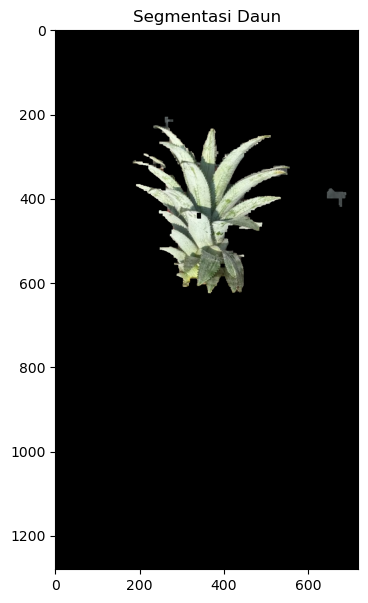

In [34]:
# Muhammad Khasyi Athallah
segmentasi_daun = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_leaf)

plt.figure(figsize=(5,7))
plt.imshow(segmentasi_daun)
plt.title('Segmentasi Daun')
plt.show()

## 8. Ringkasan Output

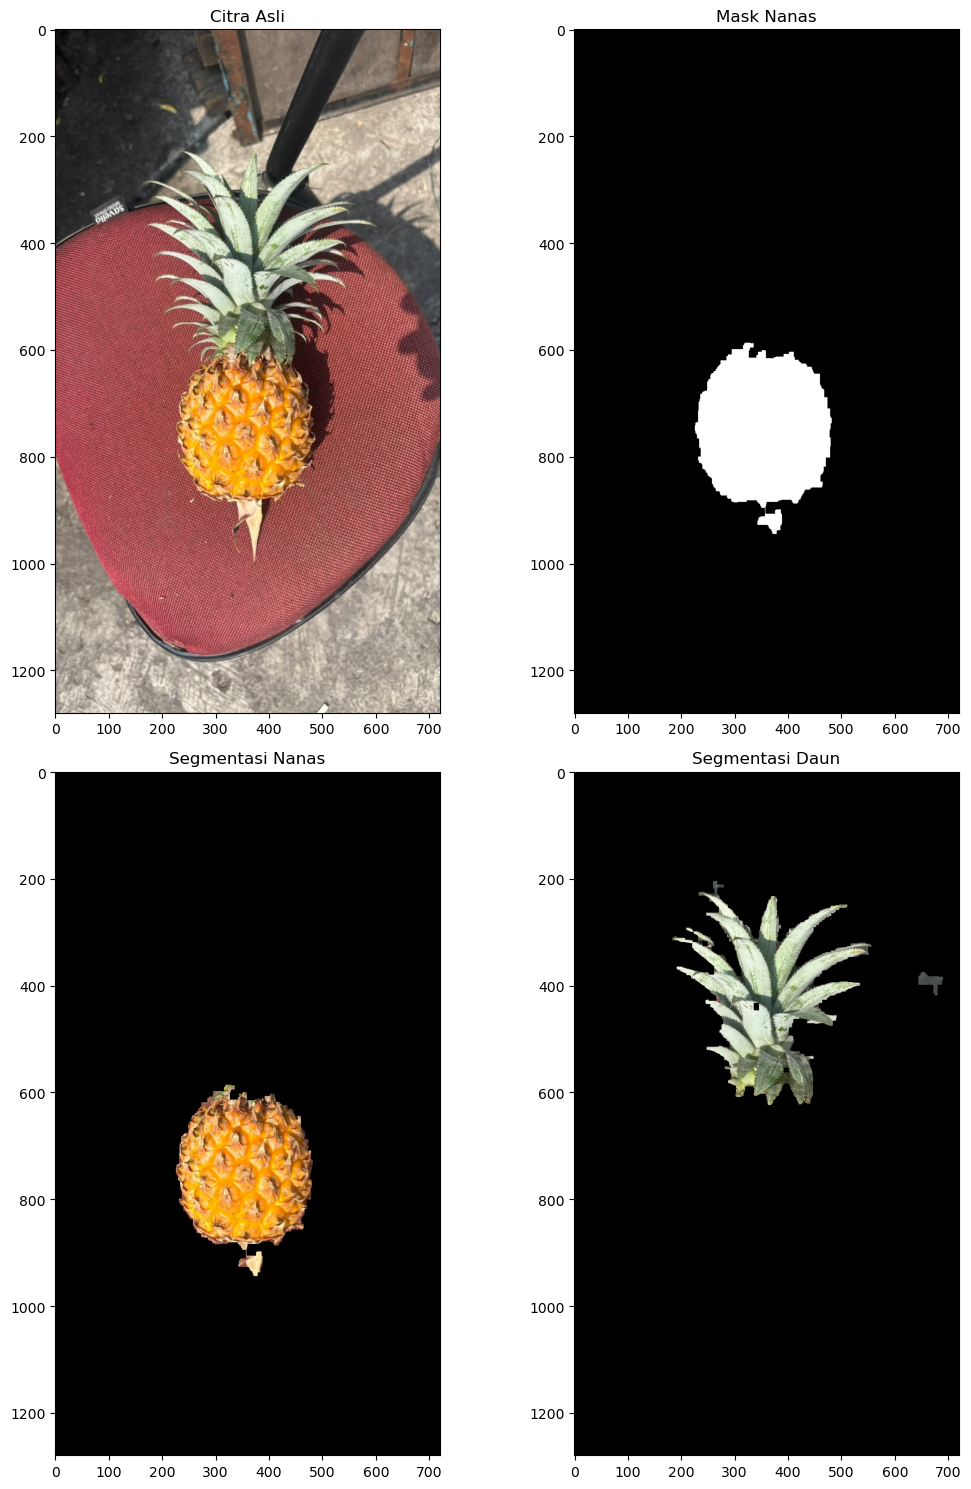

In [35]:
# Muhammad Khasyi Athallah
fig, axes = plt.subplots(2, 2, figsize=(11, 15))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Citra Asli')

axes[0, 1].imshow(mask_fruit, cmap='gray')
axes[0, 1].set_title('Mask Nanas')

axes[1, 0].imshow(segmentasi_nanas)
axes[1, 0].set_title('Segmentasi Nanas')

axes[1, 1].imshow(segmentasi_daun)
axes[1, 1].set_title('Segmentasi Daun')

plt.tight_layout()
plt.show()